# Digital Marketing Budget Allocation Under Uncertainty

## Goal

The goal of the project is to define a better policy for budget distribution for Digital Marketing advertisement sets(ad sets) on Meta Ads (Facebook/Instagram) placements aggregated in the export.
Due to the lack of purchases or revenue information the performance indicators will be two:
1. Landing Page Views(LPV)
2. Cost per LPV

<br> 

The uncertainty aspect of the project comes from the fact that there are variations of the result, which are aggregated weekly.
Instead of accurate prediction, Monte Carlo simulation with bootstrap resampling will be used in order to obtain a distribution of possible results.
In total 3 scenarios will be investigated:
- Equal distribution
- Historical average
- Risk-aware policy (maximizing the 10th percentile (P10) of LPVs or minimizing the probability that LPVs fall below a threshold)

<br>

Desired outcomes that are going to be reported for each scenario would be:
- Expected results - expected LPV and cost per LPV.
- Risk metrics(percentiles/probability of underperformance)

<br>
Practical interpretation, based on the objective of the business - "stability" or "maximizing the results"

## Data

Dataset contains Meta Ads export, on a weekly basis, for the period 01.03.2024 to 01.03.2025.

A single row in the file represents a pair Week x Ad set pair.

<br>

Key metrics that will be of interest and be used are:

- Amount spent(EUR)
- Link clicks
- Landing page views
- Impressions
- Reach
- CPC
- CPM

<br>

Campaign and ad set names are removed **Campaign ID** and **Ad set ID** will be used instead.

Main focus will be on traffic related metrics(LPV and cost per LPV) because of missing or not sufficient enough purchases/ROAS


## Metrics

### Exported metrics

1. **LPV** - Successful loading of the destination page after an ad click. [L1]
2.  **Link Cliks** - Link clicks measure the number of clicks on ad links leading to a specified destination or experience. [L2]
3.  **Impressions** - Impressions count the total number of times an advertisement is displayed. [L3]
4.  **CPM** - Cost per **1,000 impressions** [L4]
5.  **CPC** - cost per link click, derived from the equation: [L5]
$$
CPC = \cfrac{\text{Amount Spent}}{\text{Link Clicks}}
$$

### Derived metrics

1. **Cost per LPV** derivied from:
$$
\text{Cost per LPV} = \cfrac{\text{Amount Spent}}{\text{LPV}}
$$


<br>

2. **LPV rate** derived from:
$$
\text{LPV rate}= \cfrac{\text{LPV}}{\text{Link Clicks}}
$$

<br>

3. **Link CTR** derived from:
$$
\text{Link CTR} = \cfrac{\text{Link Clicks}}{\text{Impressions}}
$$

## Baseline exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

#reading of the csv file
csv_path = "../data/Meta-report-Mar-1-2024-to-Mar-1-2025.csv"
df = pd.read_csv(csv_path)

print("shape:", df.shape)
df.head(3)

shape: (83, 29)


,Week,Objective,Campaign ID,Ad set ID,Delivery status,Delivery level,Reach,Impressions,Frequency,Attribution setting,...,Clicks (all),"CPM (cost per 1,000 impressions)",Result rate,Cost per unique link click,Ad Set Budget,Ad Set Budget Type,Campaign Budget,Campaign Budget Type,Reporting starts,Reporting ends
0,2025-02-28 - 2025-03-01,LINK_CLICKS,120220823212200002,120220823212220002,completed,adset,3885,5221,1.343887,7-day click or 1-day view,...,159,1.413522,3.179468,0.050204,Using campaign budget,NaN,72,Lifetime,2025-02-28,2025-03-01
1,2025-02-21 - 2025-02-27,LINK_CLICKS,120220823212200002,120220823212220002,completed,adset,7374,16252,2.203960,7-day click or 1-day view,...,543,1.675486,4.024120,0.059325,Using campaign budget,NaN,72,Lifetime,2025-02-21,2025-02-27
2,2025-02-14 - 2025-02-20,LINK_CLICKS,120220823212200002,120220823212220002,completed,adset,3564,4504,1.263749,7-day click or 1-day view,...,165,1.307726,3.263766,0.045659,Using campaign budget,NaN,72,Lifetime,2025-02-14,2025-02-20


In [3]:
#Converting data types of collumns with Campaign and Ad set IDs as to avoid scientific notation issues
df["Campaign ID"] = df["Campaign ID"].astype("Int64").astype(str)
df["Ad set ID"] = df["Ad set ID"].astype("Int64").astype(str)
#Managing and cinvertin str data to dates for better parsing afterwards
week_split = df["Week"].str.split(" - ", expand=True)
df["week_start"] = pd.to_datetime(week_split[0], errors="coerce")
df["week_end"] = pd.to_datetime(week_split[1], errors="coerce")

In [4]:

#Computing the three desired "Derived Metrics" in order to proceed with policy evaluation later(safe division; NaN if the denominator is 0)
df["cost_per_lpv"] = np.where(df["Landing page views"] > 0,
                              df["Amount spent (EUR)"] / df["Landing page views"],
                              np.nan)

df["lpv_rate"] = np.where(df["Link clicks"] > 0,
                              df["Landing page views"] / df["Link clicks"],
                              np.nan)

df["link_ctr"] = np.where(df["Impressions"] > 0,
                              df["Link clicks"] / df["Impressions"],
                              np.nan)

df[["cost_per_lpv","lpv_rate","link_ctr"]].describe()

,cost_per_lpv,lpv_rate,link_ctr
count,69.000000,69.000000,76.000000
mean,1.086531,0.452634,0.021959
std,5.681558,0.242885,0.017771
min,0.054923,0.007380,0.000224
25%,0.140963,0.269231,0.008497
50%,0.218571,0.470000,0.017084
75%,0.346250,0.594340,0.034652
max,47.290000,0.964706,0.077851


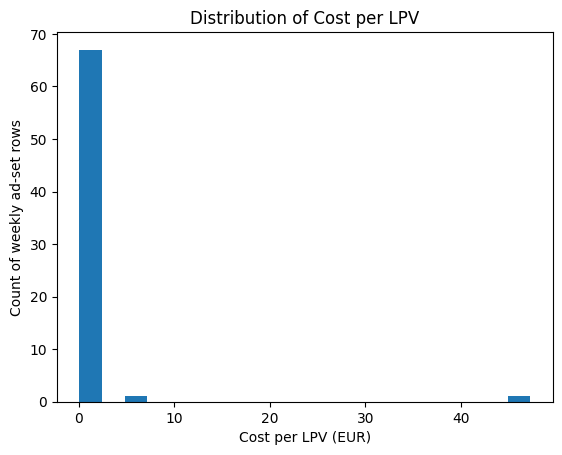

In [5]:

plt.figure()
plt.hist(df["cost_per_lpv"].dropna(), bins=20)
plt.xlabel("Cost per LPV (EUR)")
plt.ylabel("Count of weekly ad-set rows")
plt.title("Distribution of Cost per LPV")
plt.show()

1- Out of 83 weekly ad-set rows, 14 have cost_per_lpv and lpv_rate as NaN due to zero/missing denominators; link_ctr has 7 NaNs due to zero/missing impressions.
<br>
2- The distribution of cost per LPV is strongly right-skewed: median ≈ 0.22 EUR, but a small number of weeks have very high values (max ≈ 47.29 EUR).
<br>
3- Because of the long tail/outliers, risk-aware evaluation (percentiles / probability of underperformance) is more informative than only comparing averages.
<br>
4- To improve readability (since a single extreme outlier stretches the x-axis), I also include an additional histogram with the cost_per_lpv values clipped to a reasonable upper bound, so the main body of the distribution is visible.

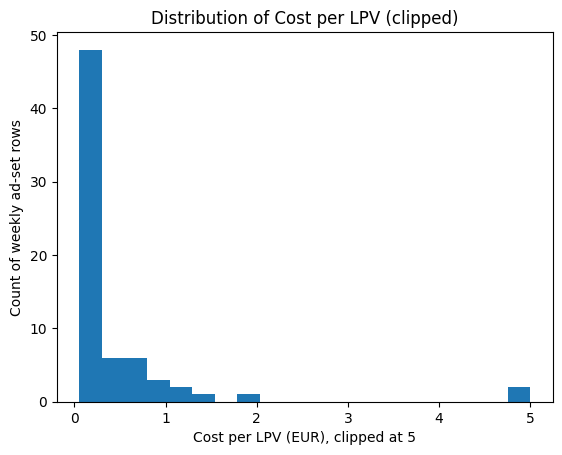

In [6]:
plt.figure()
plt.hist(df["cost_per_lpv"].dropna().clip(upper=5), bins=20)
plt.xlabel("Cost per LPV (EUR), clipped at 5")
plt.ylabel("Count of weekly ad-set rows")
plt.title("Distribution of Cost per LPV (clipped)")
plt.show()

## Next steps

## Limitations & Assumptions

## References

[L1] Meta Business Help Center - Landing Page Views - [Link](https://www.facebook.com/business/help/417293491972212?id=561906377587030)
<br>
[L2] Meta Business Help Center - Link clicks - [Link](https://www.facebook.com/business/help/284415655604125?id=354406972049255)
<br>
[L3] Meta Business Help Center - Impressions - [Link](https://www.facebook.com/business/help/675615482516035)
<br>
[L4] Meta Business Help Center - CPM - [Link](https://www.facebook.com/business/help/753932008002620?helpref=faq_content)
<br>
[L5] Meta Business Help Center - CPC (cost per link click) -  [Link](https://www.facebook.com/business/help/683065845109838?locale=bg_BG)